# This project aim to find each account representation using self supervised learning with Transformer (Encoder only model) and also clustering them with kmeans to find accounts with similar behavior

### Note: The data is synthetically generated, the goal of this project is not to find accurate predictions, instead the goal is to test an hypothesis if next transaction prediction can be a better way to identify account level self supervised representational embeddings

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, LabelEncoder
import math
# from google.colab import files
from transformer_ach.Encoder_Achitecture import FullAchitecture
import torch.nn.functional as F
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.cluster import KMeans
from sklearn.decomposition import PCA
import joblib
from sklearn.metrics import silhouette_score

In [383]:
#files.upload()

In [384]:
file_path = 'bank_transactions_data_2_augmented_clean_2.csv'

# Load the dataset
df = pd.read_csv(file_path)

In [385]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,4/11/2023 16:29,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,6/27/2023 16:44,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,7/10/2023 18:16,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,5/5/2023 16:32,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,10/16/2023 17:51,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40


In [386]:
df.describe()

,TransactionAmount,CustomerAge,TransactionDuration,LoginAttempts,AccountBalance
count,50000.000000,50000.000000,50000.000000,50000.00000,50000.000000
mean,297.872214,44.647600,118.965320,1.12684,5122.738301
std,292.818888,17.800293,70.000681,0.60936,3904.266887
min,0.240000,18.000000,10.000000,1.00000,101.250000
25%,82.897500,27.000000,63.000000,1.00000,1508.720000
50%,209.355000,45.000000,111.000000,1.00000,4735.410000
75%,409.625000,59.000000,161.000000,1.00000,7713.670000
max,2060.590000,80.000000,300.000000,5.00000,14977.990000


In [387]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 15 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   TransactionID        50000 non-null  object 
 1   AccountID            50000 non-null  object 
 2   TransactionAmount    50000 non-null  float64
 3   TransactionDate      50000 non-null  object 
 4   TransactionType      50000 non-null  object 
 5   Location             50000 non-null  object 
 6   DeviceID             50000 non-null  object 
 7   IP Address           50000 non-null  object 
 8   MerchantID           50000 non-null  object 
 9   Channel              50000 non-null  object 
 10  CustomerAge          50000 non-null  int64  
 11  CustomerOccupation   50000 non-null  object 
 12  TransactionDuration  50000 non-null  int64  
 13  LoginAttempts        50000 non-null  int64  
 14  AccountBalance       50000 non-null  float64
dtypes: float64(2), int64(3), object(10)


In [388]:
# Data type handling

df["TransactionDate"] = pd.to_datetime(df["TransactionDate"], format="mixed")

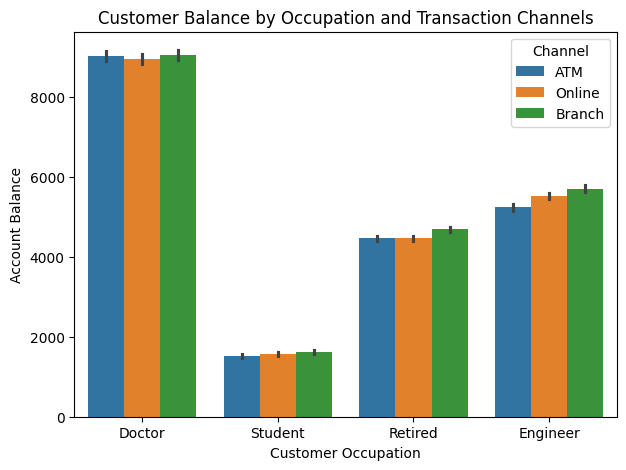

In [389]:
# Lets see who Has the most money and what channels they use the most

plt.figure(figsize=(7, 5))
sns.barplot(data=df, x="CustomerOccupation", y="AccountBalance", hue="Channel")
plt.title("Customer Balance by Occupation and Transaction Channels")
plt.xlabel("Customer Occupation")
plt.ylabel("Account Balance")
plt.show()

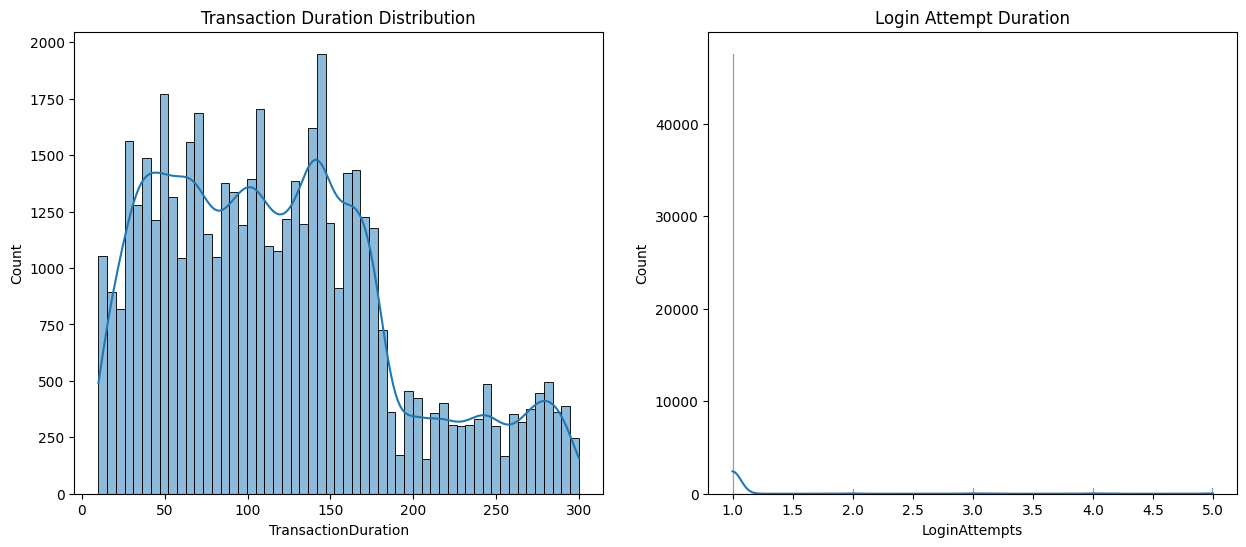

In [390]:
# Transaction duration and login attempts duration

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.histplot(data=df, x="TransactionDuration", kde=True, ax=axes[0])
sns.histplot(data=df, x="LoginAttempts", kde=True, ax=axes[1])
axes[0].set_title("Transaction Duration Distribution")
axes[1].set_title("Login Attempt Duration")
plt.show()

# Get data ready for ML

In [391]:
df.head()

,TransactionID,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
0,TX000001,AC00128,14.09,2023-04-11 16:29:00,Debit,San Diego,D000380,162.198.218.92,M015,ATM,70,Doctor,81,1,5112.21
1,TX000002,AC00455,376.24,2023-06-27 16:44:00,Debit,Houston,D000051,13.149.61.4,M052,ATM,68,Doctor,141,1,13758.91
2,TX000003,AC00019,126.29,2023-07-10 18:16:00,Debit,Mesa,D000235,215.97.143.157,M009,Online,19,Student,56,1,1122.35
3,TX000004,AC00070,184.50,2023-05-05 16:32:00,Debit,Raleigh,D000187,200.13.225.150,M002,Online,26,Student,25,1,8569.06
4,TX000005,AC00411,13.45,2023-10-16 17:51:00,Credit,Atlanta,D000308,65.164.3.100,M091,Online,26,Student,198,1,7429.40


In [392]:
# sort data by account id and date

df = df.sort_values(ascending=True, by=["AccountID", "TransactionDate"])

In [393]:
df.drop("TransactionID", axis=1, inplace=True)

- Optimization goal will be predicting Transaction type and transaction amount.....Goal is to capture users spending behavior as representations

In [394]:
df.head()

,AccountID,TransactionAmount,TransactionDate,TransactionType,Location,DeviceID,IP Address,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance
32405,AC00001,47.68,2020-01-29,Debit,Denver,D000649,59.12.96.11,M034,Branch,25,Student,37,1,1649.92
16120,AC00001,46.05,2020-02-16,Debit,Denver,D000649,59.12.96.11,M034,Branch,25,Student,37,1,1649.92
31291,AC00001,44.39,2020-04-23,Debit,Denver,D000649,59.12.96.11,M034,Branch,25,Student,37,1,1649.92
22029,AC00001,48.96,2020-06-16,Debit,Denver,D000649,59.12.96.11,M034,Branch,25,Student,37,1,1649.92
24311,AC00001,50.06,2020-08-16,Debit,Denver,D000649,59.12.96.11,M034,Branch,25,Student,37,1,1649.92


In [395]:
# Extract datetime features
df["TransactionDay"] = df["TransactionDate"].dt.day
df["TransactionMonth"] = df["TransactionDate"].dt.month

# Take each account transaction day and find their transaction difference
df["DateDifference"] = (
df.groupby("AccountID")["TransactionDate"]
  .diff().dt.days
)
df.drop(["TransactionDate", "DeviceID", "IP Address"], axis=1, inplace=True)

In [396]:
df.dropna(inplace=True)

In [397]:
df_enc = df.copy()

In [ ]:
# group data and split
train_list = []
test_list = []
for acc, group in df.groupby("AccountID"):
    """
    for each account, split by last 20% of transactions
    """
    split = int(0.9 * len(group))
    train_data = group[:split]
    test_data = group[split:]

    train_list.append(train_data)
    test_list.append(test_data)

In [ ]:
# Since the train and test dataframe are in a list, lets put them back in pandas df format

train_df = pd.DataFrame(columns=df.columns)
test_df = pd.DataFrame(columns=df.columns)

train_df

for i in range(len(train_list)):

    train_df = pd.concat([train_df, train_list[i]], ignore_index=True)

test_df

for i in range(len(test_list)):

    test_df = pd.concat([test_df, test_list[i]], ignore_index=True)

In [401]:
train_df.dtypes

AccountID               object
TransactionAmount      float64
TransactionType         object
Location                object
MerchantID              object
Channel                 object
CustomerAge             object
CustomerOccupation      object
TransactionDuration     object
LoginAttempts           object
AccountBalance         float64
TransactionDay          object
TransactionMonth        object
DateDifference         float64
dtype: object

In [402]:
train_df["CustomerAge"] = train_df["CustomerAge"].astype(int)
train_df["TransactionDuration"] = train_df["TransactionDuration"].astype(int)

test_df["CustomerAge"] = test_df["CustomerAge"].astype(int)
test_df["TransactionDuration"] = test_df["TransactionDuration"].astype(int)

In [403]:
cat_cols = []
num_cols = []

for col in train_df.columns:
    if train_df[col].dtype == "object":
        cat_cols.append(col)
    else:
        num_cols.append(col)

cat_cols.remove("AccountID")

In [404]:
# Label Encode and Scale numerical features

def preprocessing(train_df, test_df):
    Encoder ={}
    num_encoder = {}

    for i in cat_cols:
        le = LabelEncoder()
        train_df[i] = le.fit_transform(train_df[i])
        Encoder[i]=le
        test_df[i] = Encoder[i].transform(test_df[i])

    for i in num_cols:
        ss = StandardScaler()
        train_df[i] = ss.fit_transform(train_df[i].values.reshape(-1, 1))
        test_df[i] = ss.transform(test_df[i].values.reshape(-1, 1))
        num_encoder[i] = ss

    return train_df, test_df, Encoder, num_encoder

In [405]:
train_df, test_df, encoder, num_encoder = preprocessing(train_df, test_df)

In [ ]:
# Create Features and Target for each account last 5 sliding windows

def to_array(train_df):

    rem_acc = train_df.columns.to_list()
    rem_acc.remove("AccountID")

    X = []
    y = []

    for acc, group in train_df.groupby("AccountID"):

        # 5 input transactions + 1 target transaction
        for i in range(len(group) - 10):

            # T_i ... T_i+9
            feat = group[rem_acc].iloc[i:i+10]

            # T_i+10 (the next transaction)
            targ = group[[
                "TransactionAmount",
                "DateDifference"
            ]].iloc[i+10]

            X.append(feat.to_numpy())
            y.append(targ.to_numpy())

    return np.array(X), np.array(y)

In [407]:
X_train, y_train = to_array(train_df)
X_test, y_test = to_array(test_df)

In [408]:
embed_feat = []

for i in train_df.columns:
    if df[i].dtypes != "float64":
        embed_feat.append(i)

# Pytorch dataset

In [409]:
device = "cuda" if torch.cuda.is_available() else "cpu"
device

'cpu'

In [410]:
X_train_tensor = torch.tensor(X_train, dtype=torch.float).to(device)
y_train_tensor = torch.tensor(y_train, dtype=torch.float).to(device)

X_test_tensor = torch.tensor(X_test, dtype=torch.float).to(device)
y_test_tensor = torch.tensor(y_test, dtype=torch.float).to(device)

In [411]:
train_dataset = TensorDataset(X_train_tensor, y_train_tensor)
test_dataset = TensorDataset(X_test_tensor, y_test_tensor)

In [412]:
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)
test_loader = DataLoader(test_dataset, batch_size=32, shuffle=True)

In [413]:
# find the cat cols to embed

X_train[:, :, 1] # Transaction Type
X_train[:, :, 2] # Location
X_train[:, :, 3] # Merchant ID
X_train[:, :, 4] # Channel
X_train[:, :, 6] # Customer_Occupation
X_train[:, :, 8] # LoginAttempts
X_train[:, :, 10] # Transaction Day
X_train[:, :, 11] # Transaction Month
X_train[:, :, 12] # Date Difference

# So i am creating 8 embeddings

array([[-0.11445377,  1.73831211,  1.24676198, ...,  3.02390475,
         4.34730895, -0.68162699],
       [ 1.73831211,  1.24676198,  1.51144282, ...,  4.34730895,
        -0.68162699,  0.26366172],
       [ 1.24676198,  1.51144282, -0.71943854, ..., -0.68162699,
         0.26366172,  2.11642759],
       ...,
       [-0.26569996,  0.49053101, -0.71943854, ..., -0.07664222,
         1.09551578,  0.5661541 ],
       [ 0.49053101, -0.71943854,  0.60396565, ...,  1.09551578,
         0.5661541 , -0.5303808 ],
       [-0.71943854,  0.60396565,  1.9651814 , ...,  0.5661541 ,
        -0.5303808 , -0.11445377]], shape=(39387, 10))

In [419]:
model = FullAchitecture(405, 1).to(device)
# For numerical
mse = nn.MSELoss()
epochs = 20
optimizer = torch.optim.Adam(model.parameters(), lr=0.0001)

In [ ]:
def trainer(model, optimizer, mse_loss, train_loader, val_loader, epochs, patience=5):

    best_val_loss = float("inf")
    patience_counter = 0
    best_model_state = None

    for epoch in range(epochs):

        # TRAIN

        model.train()

        total_date_loss = 0
        total_amount_loss = 0

        for X_batch, y_batch in train_loader:

            X_batch = X_batch.to(device)
            y_batch = y_batch.to(device)

            optimizer.zero_grad()

            _, date_pred, amount_pred = model(X_batch)


            # Target = 10 transaction
            # y_batch shape: (batch, 2)
            #
            # column 0 = TransactionAmount
            # column 1 = DateDifference

            amount_target = y_batch[:, 0].float()
            date_target = y_batch[:, 1].float()

            date_pred = date_pred.squeeze(-1)
            amount_pred = amount_pred.squeeze(-1)

            # Regression losses

            date_loss = mse_loss(date_pred, date_target)

            amount_loss = mse_loss(amount_pred, amount_target)

            # Combined loss
            loss = date_loss + amount_loss

            loss.backward()
            optimizer.step()

            total_date_loss += date_loss.item()
            total_amount_loss += amount_loss.item()

        avg_train_date = total_date_loss / len(train_loader)
        avg_train_amount = total_amount_loss / len(train_loader)

        avg_train_loss = avg_train_date + avg_train_amount


        # VALIDATION

        model.eval()

        total_val_date_loss = 0
        total_val_amount_loss = 0

        total_date_abs_error = 0
        total_date_squared_error = 0

        total_amount_abs_error = 0
        total_amount_squared_error = 0

        total = 0

        with torch.no_grad():

            for X_batch, y_batch in val_loader:

                X_batch = X_batch.to(device)
                y_batch = y_batch.to(device)

                _, date_pred, amount_pred = model(X_batch)

                # Targets
                amount_target = y_batch[:, 0].float()
                date_target = y_batch[:, 1].float()

                date_pred = date_pred.squeeze(-1)
                amount_pred = amount_pred.squeeze(-1)

                # Losses

                date_loss = mse_loss(
                    date_pred,
                    date_target
                )

                amount_loss = mse_loss(
                    amount_pred,
                    amount_target
                )

                total_val_date_loss += date_loss.item()
                total_val_amount_loss += amount_loss.item()

                # Date metrics

                date_errors = date_pred - date_target

                total_date_abs_error += (
                    date_errors.abs().sum().item()
                )

                total_date_squared_error += (
                    (date_errors ** 2).sum().item()
                )

                # Amount metrics

                amount_errors = amount_pred - amount_target

                total_amount_abs_error += (
                    amount_errors.abs().sum().item()
                )

                total_amount_squared_error += (
                    (amount_errors ** 2).sum().item()
                )

                total += y_batch.size(0)

        # AVERAGE VALIDATION RESULTS

        avg_val_date = total_val_date_loss / len(val_loader)
        avg_val_amount = total_val_amount_loss / len(val_loader)

        avg_val_loss = avg_val_date + avg_val_amount

        # Date metrics
        date_mae = total_date_abs_error / total

        date_rmse = (
            total_date_squared_error / total
        ) ** 0.5

        # Amount metrics
        amount_mae = total_amount_abs_error / total

        amount_rmse = (
            total_amount_squared_error / total
        ) ** 0.5

        # PRINT

        print(
            f"Epoch {epoch + 1}/{epochs} | "
            f"Train Loss: {avg_train_loss:.4f} | "
            f"Val Loss: {avg_val_loss:.4f} | "
            f"Date Loss: {avg_val_date:.4f} | "
            f"Amount Loss: {avg_val_amount:.4f} | "
            f"Date MAE: {date_mae:.4f} | "
            f"Date RMSE: {date_rmse:.4f} | "
            f"Amount MAE: {amount_mae:.4f} | "
            f"Amount RMSE: {amount_rmse:.4f}"
        )

        # EARLY STOPPING

        if avg_val_loss < best_val_loss:

            best_val_loss = avg_val_loss
            patience_counter = 0

            best_model_state = {
                key: value.detach().cpu().clone()
                for key, value in model.state_dict().items()
            }

            print("Validation improved. Saving model.")

        else:

            patience_counter += 1

            print(
                f"No improvement"
                f"({patience_counter}/{patience})"
            )

            if patience_counter >= patience:

                print("Early stopping triggered.")

                model.load_state_dict(best_model_state)

                break


    # Restore best model
    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    print(f"\nBest validation loss: {best_val_loss:.4f}")

    return model

In [421]:
model = trainer(model=model, optimizer=optimizer, mse_loss=mse, train_loader=train_loader,
                val_loader=test_loader, epochs=20, patience=5)

Epoch 1/20 | Train Loss: 1.6924 | Val Loss: 1.3809 | Date Loss: 0.3474 | Amount Loss: 1.0334 | Date MAE: 0.4462 | Date RMSE: 0.5894 | Amount MAE: 0.7715 | Amount RMSE: 1.0057
  → Validation improved. Saving model.
Epoch 2/20 | Train Loss: 1.6224 | Val Loss: 1.4154 | Date Loss: 0.3414 | Amount Loss: 1.0739 | Date MAE: 0.4421 | Date RMSE: 0.5832 | Amount MAE: 0.7303 | Amount RMSE: 1.0384
  → No improvement (1/5)
Epoch 3/20 | Train Loss: 1.6068 | Val Loss: 1.3397 | Date Loss: 0.3345 | Amount Loss: 1.0051 | Date MAE: 0.4266 | Date RMSE: 0.5782 | Amount MAE: 0.7531 | Amount RMSE: 1.0003
  → Validation improved. Saving model.
Epoch 4/20 | Train Loss: 1.5907 | Val Loss: 1.3440 | Date Loss: 0.3396 | Amount Loss: 1.0044 | Date MAE: 0.4497 | Date RMSE: 0.5843 | Amount MAE: 0.7699 | Amount RMSE: 1.0020
  → No improvement (1/5)
Epoch 5/20 | Train Loss: 1.5826 | Val Loss: 1.3453 | Date Loss: 0.3467 | Amount Loss: 0.9986 | Date MAE: 0.4439 | Date RMSE: 0.5840 | Amount MAE: 0.7482 | Amount RMSE: 1.00

In [422]:
# Evaluation

date_pred_list = []
amount_pred_list = []
date_actual_list = []
amount_actual_list = []

with torch.no_grad():
    for X_batch, y_batch in test_loader:
        X_batch = X_batch.to(device)
        y_batch = y_batch.to(device)

        _, date_pred, amount_pred = model(X_batch)

        # Targets
        amount_target = y_batch[:, 0].float()
        date_target = y_batch[:, 1].float()

        date_pred = date_pred.squeeze(-1)
        amount_pred = amount_pred.squeeze(-1)

        date_pred_list.extend(date_pred.cpu().numpy())
        amount_pred_list.extend(amount_pred.cpu().numpy())
        date_actual_list.extend(date_target.cpu().numpy())
        amount_actual_list.extend(amount_target.cpu().numpy())

In [423]:
date_pred_list = [float(x) for x in date_pred_list]
amount_pred_list = [float(x) for x in amount_pred_list]

date_actual_list = [float(x) for x in date_actual_list]
amount_actual_list = [float(x) for x in amount_actual_list]

In [424]:
# Reverse transform

date_pred_list = num_encoder["DateDifference"].inverse_transform(np.array(date_pred_list).reshape(-1, 1)).flatten()
amount_pred_list = num_encoder["TransactionAmount"].inverse_transform(np.array(amount_pred_list).reshape(-1, 1)).flatten()

date_actual_list = num_encoder["DateDifference"].inverse_transform(np.array(date_actual_list).reshape(-1, 1)).flatten()
amount_actual_list = num_encoder["DateDifference"].inverse_transform(np.array(amount_actual_list).reshape(-1, 1)).flatten()

In [425]:
date_actual_list

array([ 1.00000003e+01,  4.40000003e+01,  1.99999971e+00, ...,
        1.99999971e+00, -2.41155288e-07,  3.00000047e+00], shape=(1013,))

In [426]:
# Evaluate values

mse = mean_squared_error(date_actual_list, date_pred_list)
mae = mean_absolute_error(date_actual_list, date_pred_list)

amount_mse = mean_squared_error(amount_actual_list, amount_pred_list)
amount_mae = mean_absolute_error(amount_actual_list, amount_pred_list)

print(f"Date MSE: {mse:.4f}")
print(f"Date MAE: {mae:.4f}")
print(f"Amount MSE: {amount_mse:.4f}")
print(f"Amount MAE: {amount_mae:.4f}")

Date MSE: 228.6782
Date MAE: 10.7891
Amount MSE: 87715.8584
Amount MAE: 279.1616


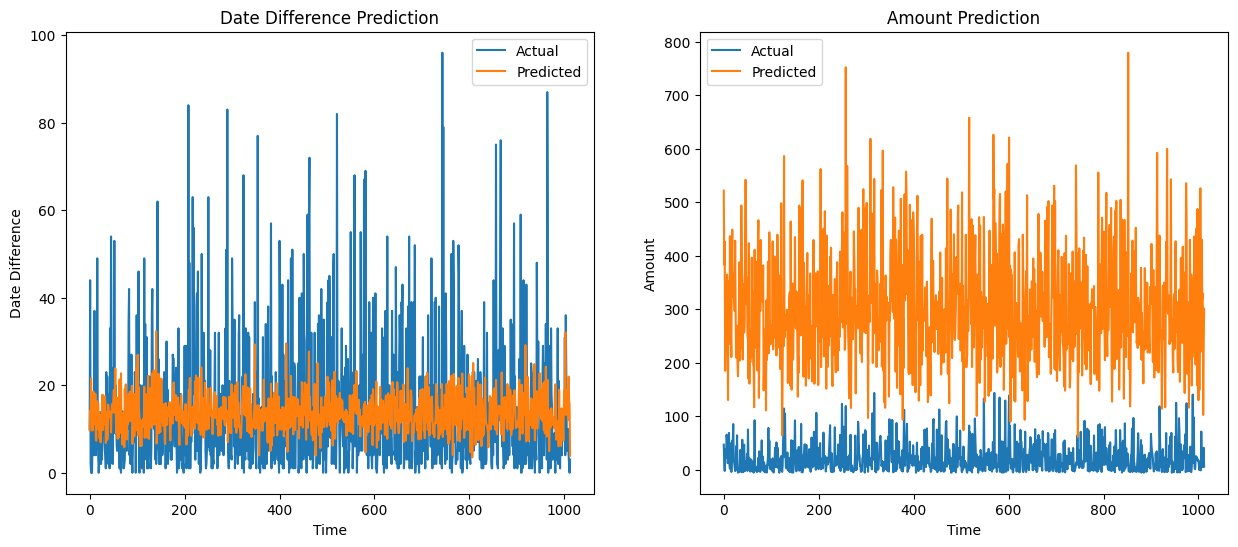

In [427]:
# Visualization of Predictions

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

sns.lineplot(x=range(len(date_actual_list)), y=date_actual_list, label="Actual", ax=axes[0])
sns.lineplot(x=range(len(date_pred_list)), y=date_pred_list, label="Predicted", ax=axes[0])
axes[0].set_title("Date Difference Prediction")
axes[0].set_xlabel("Time")
axes[0].set_ylabel("Date Difference")

sns.lineplot(x=range(len(amount_actual_list)), y=amount_actual_list, label="Actual", ax=axes[1])
sns.lineplot(x=range(len(amount_pred_list)), y=amount_pred_list, label="Predicted", ax=axes[1])
axes[1].set_title("Amount Prediction")
axes[1].set_xlabel("Time")
axes[1].set_ylabel("Amount")
plt.show()

# Grabbing Embeddings



In [428]:
for i in encoder.keys():
      df[i] = encoder[i].transform(df[i])

for j in num_encoder.keys():
      df[j] = num_encoder[j].transform(df[[j]])



c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was fitted without feature names
  warnings.warn(
c:\Users\USER\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\utils\validation.py:2684: UserWarning: X has feature names, but StandardScaler was f

In [429]:
df.head()

,AccountID,TransactionAmount,TransactionType,Location,MerchantID,Channel,CustomerAge,CustomerOccupation,TransactionDuration,LoginAttempts,AccountBalance,TransactionDay,TransactionMonth,DateDifference
16120,AC00001,-0.861082,1,10,33,1,-1.105602,3,-1.172777,0,-0.889697,15,1,-0.114454
31291,AC00001,-0.866757,1,10,33,1,-1.105602,3,-1.172777,0,-0.889697,22,3,1.738312
22029,AC00001,-0.851136,1,10,33,1,-1.105602,3,-1.172777,0,-0.889697,15,5,1.246762
24311,AC00001,-0.847375,1,10,33,1,-1.105602,3,-1.172777,0,-0.889697,15,7,1.511443
3677,AC00001,-0.855579,1,10,33,1,-1.105602,3,-1.172777,0,-0.889697,17,7,-0.719439


In [430]:
# Lets get out embeddings for each account

representations = {}
account = []

with torch.no_grad():
  for acc, group in df.groupby("AccountID"):
    columns = train_df.columns.to_list()
    columns.remove("AccountID")

    if len(group) > 500:
      account.append(acc)
      data_points = np.array(group[columns][:-500])
    else:
      data_points = np.array(group[columns])
      
      
    tensor_points = torch.tensor(data_points, dtype=torch.float, device=device).unsqueeze(0)
    embed, _, _ = model(tensor_points)

    embeddings = embed.squeeze(-1)

    representations[acc] = embeddings

if not account:
  print("All accounts have 500 and below transactions")


All accounts have 500 and below transactions


In [431]:
print(f"Total number of accounts are {len(representations)}")

Total number of accounts are 495


In [ ]:
torch.save(model.state_dict(), "Representational_Learning.pt")
joblib.dump(encoder, "label_encoders.pkl")
joblib.dump(num_encoder, "standard_scalers.pkl")

In [434]:
with open("feature_arangement.txt", "w", encoding="UTF8") as f:
    for col in columns:
        f.write(f"{col}\n")

# lets visualize each representations with their clusters using KMeans

In [435]:
embeddings = [value.cpu().numpy() for key, value in representations.items()]

In [436]:
acc_emb = [arr.squeeze(0).tolist() for arr in embeddings]

In [437]:
kmeans = KMeans(n_clusters=4)
pca = PCA(n_components=2)

In [438]:
# fit PCA with my data so i can get vector of 2 array each]

X_data = np.array(acc_emb)

X_pca = pca.fit_transform(X_data)

kmeans.fit(X_pca)

,"n_clusters n_clusters: int, default=8The number of clusters to form as well as the number ofcentroids to generate.For an example of how to choose an optimal value for `n_clusters` refer to:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_silhouette_analysis.py`.",4
,"init init: {'k-means++', 'random'}, callable or array-like of shape (n_clusters, n_features), default='k-means++'Method for initialization:* 'k-means++' : selects initial cluster centroids using sampling based on an empirical probability distribution of the points' contribution to the overall inertia. This technique speeds up convergence. The algorithm implemented is ""greedy k-means++"". It differs from the vanilla k-means++ by making several trials at each sampling step and choosing the best centroid among them.* 'random': choose `n_clusters` observations (rows) at random from data for the initial centroids.* If an array is passed, it should be of shape (n_clusters, n_features) and gives the initial centers.* If a callable is passed, it should take arguments X, n_clusters and a random state and return an initialization.For an example of how to use the different `init` strategies, see:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_digits.py`.For an evaluation of the impact of initialization, see the example:ref:`sphx_glr_auto_examples_cluster_plot_kmeans_stability_low_dim_dense.py`.",'k-means++'
,"n_init n_init: 'auto' or int, default='auto'Number of times the k-means algorithm is run with different centroidseeds. The final results is the best output of `n_init` consecutive runsin terms of inertia. Several runs are recommended for sparsehigh-dimensional problems (see :ref:`kmeans_sparse_high_dim`).When `n_init='auto'`, the number of runs depends on the value of init:10 if using `init='random'` or `init` is a callable;1 if using `init='k-means++'` or `init` is an array-like... versionadded:: 1.2 Added 'auto' option for `n_init`... versionchanged:: 1.4 Default value for `n_init` changed to `'auto'`.",'auto'
,"max_iter max_iter: int, default=300Maximum number of iterations of the k-means algorithm for asingle run.",300
,"tol tol: float, default=1e-4Relative tolerance with regards to Frobenius norm of the differencein the cluster centers of two consecutive iterations to declareconvergence.",0.0001
,"verbose verbose: int, default=0Verbosity mode.",0
,"random_state random_state: int, RandomState instance or None, default=NoneDetermines random number generation for centroid initialization. Usean int to make the randomness deterministic.See :term:`Glossary `.",None
,"copy_x copy_x: bool, default=TrueWhen pre-computing distances it is more numerically accurate to centerthe data first. If copy_x is True (default), then the original data isnot modified. If False, the original data is modified, and put backbefore the function returns, but small numerical differences may beintroduced by subtracting and then adding the data mean. Note that ifthe original data is not C-contiguous, a copy will be made even ifcopy_x is False. If the original data is sparse, but not in CSR format,a copy will be made even if copy_x is False.",True
,"algorithm algorithm: {""lloyd"", ""elkan""}, default=""lloyd""K-means algorithm to use. The classical EM-style algorithm is `""lloyd""`.The `""elkan""` variation can be more efficient on some datasets withwell-defined clusters, by using the triangle inequality. However it'smore memory intensive due to the allocation of an extra array of shape`(n_samples, n_clusters)`... versionchanged:: 0.18 Added Elkan algorithm.. versionchanged:: 1.1 Renamed ""full"" to ""lloyd"", and deprecated ""auto"" and ""full"". Changed ""auto"" to use ""lloyd"" instead of ""elkan"".",'lloyd'


In [439]:
clus_data = pd.DataFrame({"PCA_1": X_pca[:, 0], "PCA_2": X_pca[:, 1], "Cluster": kmeans.labels_})

In [440]:
clus_data.head()

,PCA_1,PCA_2,Cluster
0,-1.672293,0.309408,1
1,0.942986,0.092461,3
2,0.873252,0.471782,3
3,1.379229,0.939267,3
4,1.098042,0.183326,3


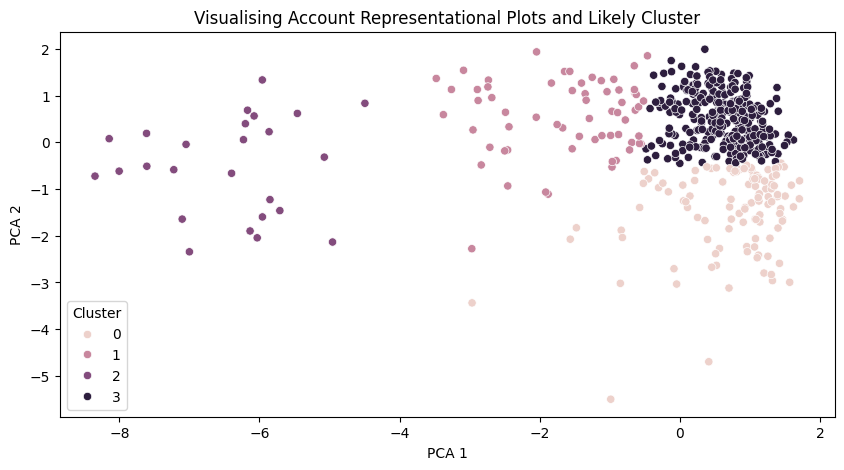

In [441]:
plt.figure(figsize=(10, 5))
sns.scatterplot(data=clus_data, x="PCA_1", y="PCA_2", hue="Cluster")
plt.title("Visualising Account Representational Plots and Likely Cluster")
plt.xlabel("PCA 1")
plt.ylabel("PCA 2")
plt.show()

In [442]:
clus_data.insert(0, "Account ID", representations.keys())

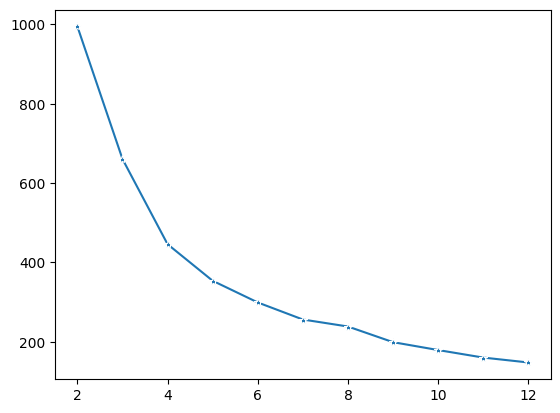

In [443]:
# Lets find the best number of clusters

ran = [i for i in range(2, 13)]

sil_scores = []
inertia_score = []

for i in ran:
    mod = KMeans(n_clusters=i)
    mod.fit(X_pca)
    sil = silhouette_score(X_pca, mod.labels_)
    inn = mod.inertia_
    sil_scores.append(sil)
    inertia_score.append(inn)

sns.lineplot(x=ran, y=inertia_score, marker="*")
plt.show()

In [444]:
print(f"Best cluster number is {sil_scores.index(max(sil_scores))+2}")

Best cluster number is 2


In [445]:
# will continue using 4 because is the second best and we still have oppurtunities to segment further
# I cant remember the easier function but this will take time

df_enc["Labels"] = None
#eval_df = pd.DataFrame(columns=df_enc.columns)

for i in range(len(df_enc)):

    acc_id = df_enc.iloc[i, 0]

    lab = clus_data[clus_data["Account ID"] == acc_id]["Cluster"].to_list()[0]

    df_enc.iloc[i, -1] = lab

    #eval_df = pd.concat([eval_df, df_enc], ignore_index=True)

In [446]:
label0 = df_enc[df_enc["Labels"] == 0]
label1 = df_enc[df_enc["Labels"] == 1]
label2 = df_enc[df_enc["Labels"] == 2]
label3 = df_enc[df_enc["Labels"] == 3]

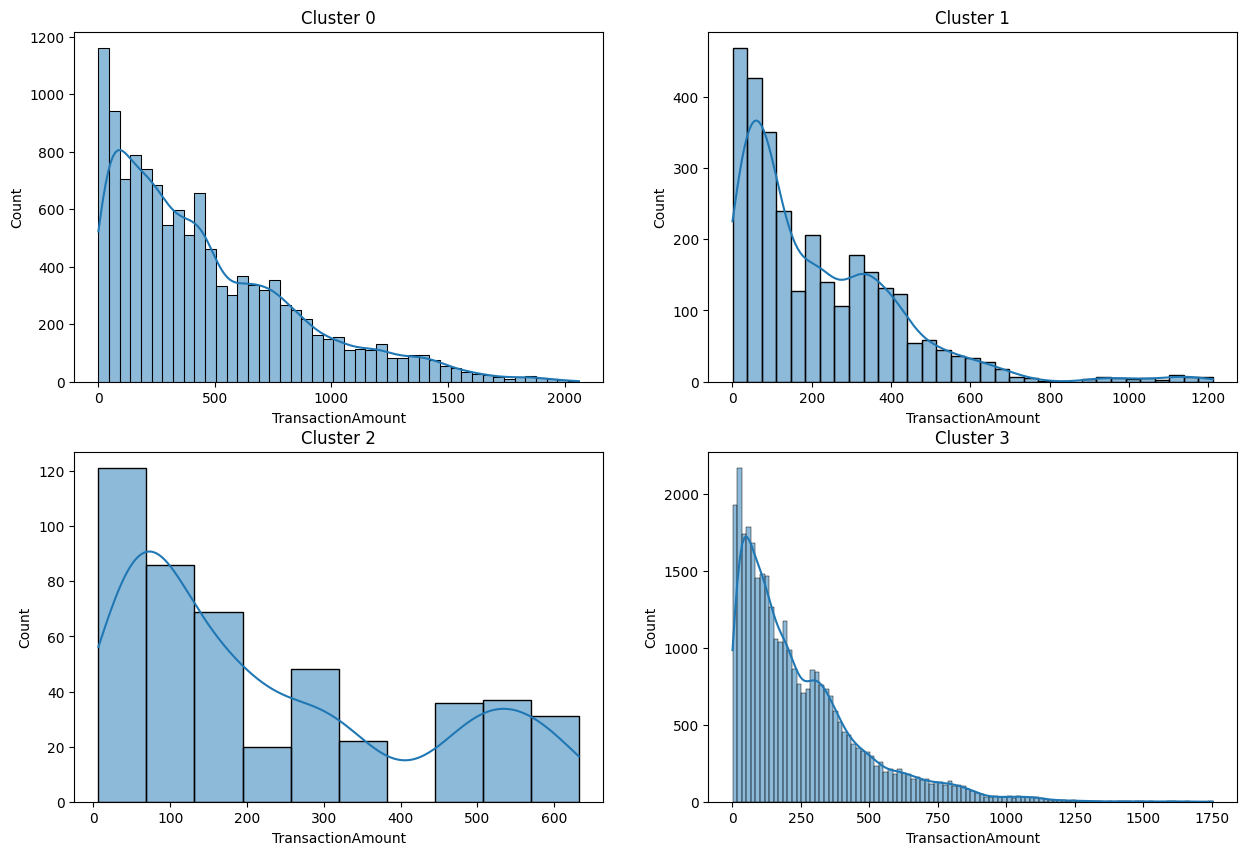

In [447]:
# Distribution of cashflow

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(data=label0, x="TransactionAmount", kde=True, ax=axes[0,0])
sns.histplot(data=label1, x="TransactionAmount", kde=True, ax=axes[0,1])
sns.histplot(data=label2, x="TransactionAmount", kde=True, ax=axes[1,0])
sns.histplot(data=label3, x="TransactionAmount", kde=True, ax=axes[1,1])
axes[0,0].set_title("Cluster 0")
axes[0,1].set_title("Cluster 1")
axes[1,0].set_title("Cluster 2")
axes[1,1].set_title("Cluster 3")

plt.show()

In [463]:
print("Average day between transactions")
print(df_enc.groupby("Labels")["DateDifference"].mean())
print("===" * 50)
print("Average account balance")
print(df_enc.groupby("Labels")["AccountBalance"].mean())
print("===" * 50)
print("Average Customer Age")
print(df_enc.groupby("Labels")["CustomerAge"].mean())
print("===" * 50)
print("Average Transaction Amount or Cashflow")
print(df_enc.groupby("Labels")["TransactionAmount"].mean())
print("===" * 50)
print("Average Time Spent Transaction (seconds)")
print(df_enc.groupby("Labels")["TransactionDuration"].mean())

Average day between transactions
Labels
0     19.952647
1     44.741039
2    105.717021
3     18.510498
Name: DateDifference, dtype: float64
Average account balance
Labels
0    5046.964195
1    5534.898781
2    4665.063426
3    5117.155503
Name: AccountBalance, dtype: float64
Average Customer Age
Labels
0    43.574231
1    43.982245
2    43.425532
3    45.115517
Name: CustomerAge, dtype: float64
Average Transaction Amount or Cashflow
Labels
0    463.449297
1    214.570938
2    225.885234
3    246.783257
Name: TransactionAmount, dtype: float64
Average Time Spent Transaction (seconds)
Labels
0    119.388018
1    127.139698
2    133.374468
3    117.900221
Name: TransactionDuration, dtype: float64


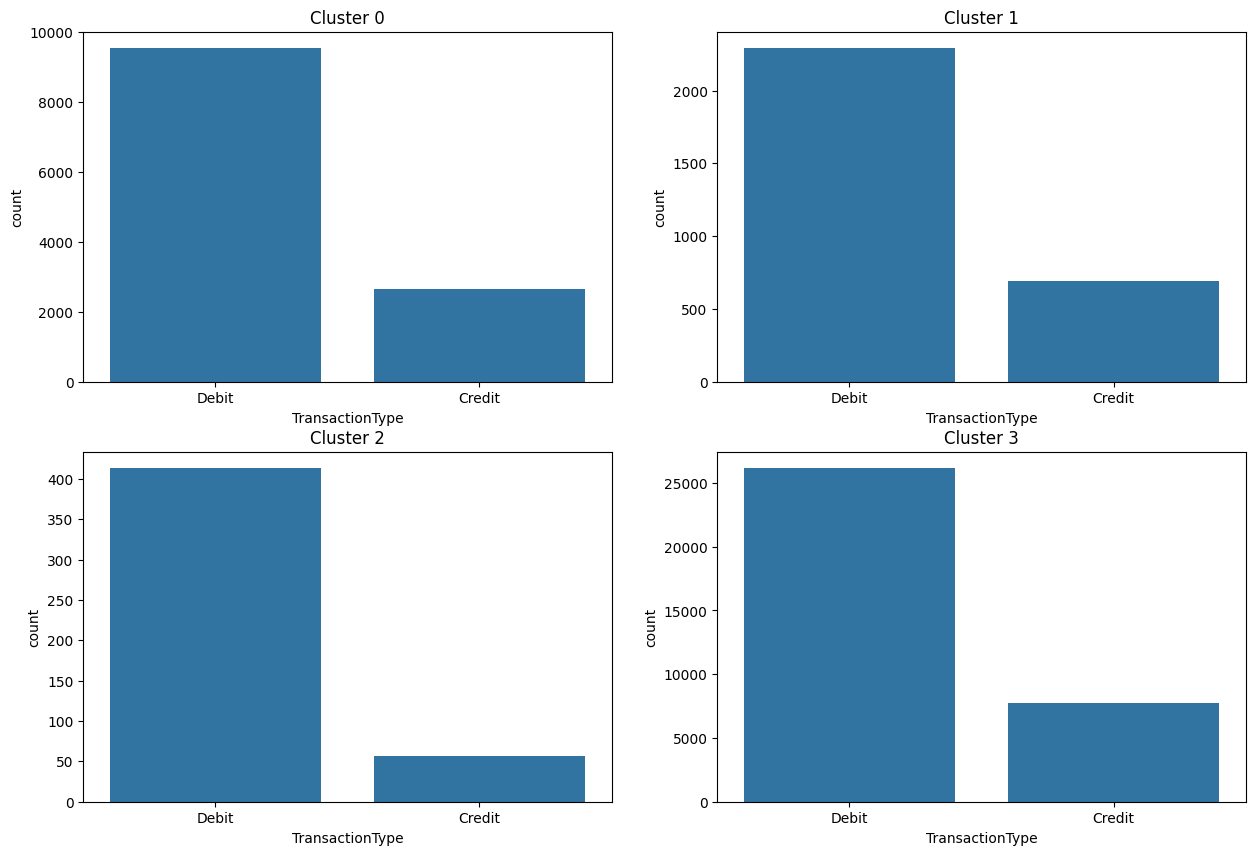

In [ ]:
# Barplot for Transaction Type

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=label0, x="TransactionType", ax=axes[0,0])
sns.countplot(data=label1, x="TransactionType", ax=axes[0,1])
sns.countplot(data=label2, x="TransactionType", ax=axes[1,0])
sns.countplot(data=label3, x="TransactionType", ax=axes[1,1])
axes[0,0].set_title("Cluster 0")
axes[0,1].set_title("Cluster 1")
axes[1,0].set_title("Cluster 2")
axes[1,1].set_title("Cluster 3")
plt.show()

In [458]:
# View credit to total transactions percentage
clus_0 = len(label0[label0["TransactionType"] == "Credit"]) / len(label0)
clus_1 = len(label1[label1["TransactionType"] == "Credit"]) / len(label1)
clus_2 = len(label2[label2["TransactionType"] == "Credit"]) / len(label2)
clus_3 = len(label3[label3["TransactionType"] == "Credit"]) / len(label3)

print(f"Cluster 0 has {clus_0*100:.1f}% credit to total transactions")
print(f"Cluster 1 has {clus_1*100:.1f}% credit to total transactions")
print(f"Cluster 2 has {clus_2*100:.1f}% credit to total transactions")
print(f"Cluster 3 has {clus_3*100:.1f}% credit to total transactions")

Cluster 0 has 21.8% credit to total transactions
Cluster 1 has 23.3% credit to total transactions
Cluster 2 has 12.1% credit to total transactions
Cluster 3 has 22.8% credit to total transactions


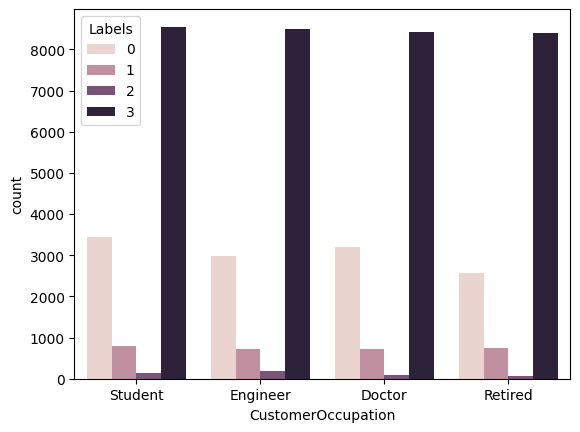

In [450]:
sns.countplot(data=df_enc, x="CustomerOccupation", hue="Labels")
plt.show()

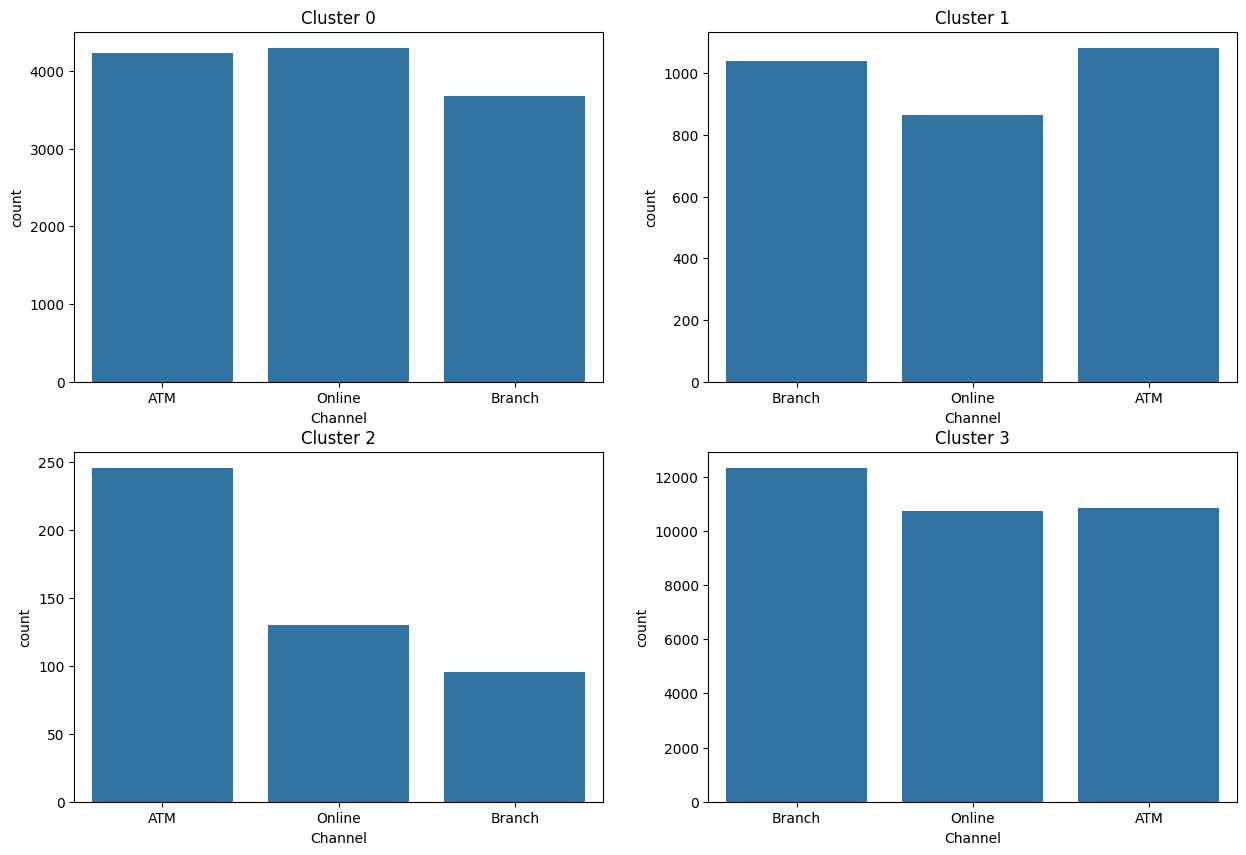

In [ ]:
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.countplot(data=label0, x="Channel", ax=axes[0,0])
sns.countplot(data=label1, x="Channel", ax=axes[0,1])
sns.countplot(data=label2, x="Channel", ax=axes[1,0])
sns.countplot(data=label3, x="Channel", ax=axes[1,1])

axes[0,0].set_title("Cluster 0")
axes[0,1].set_title("Cluster 1")
axes[1,0].set_title("Cluster 2")
axes[1,1].set_title("Cluster 3")
plt.show()

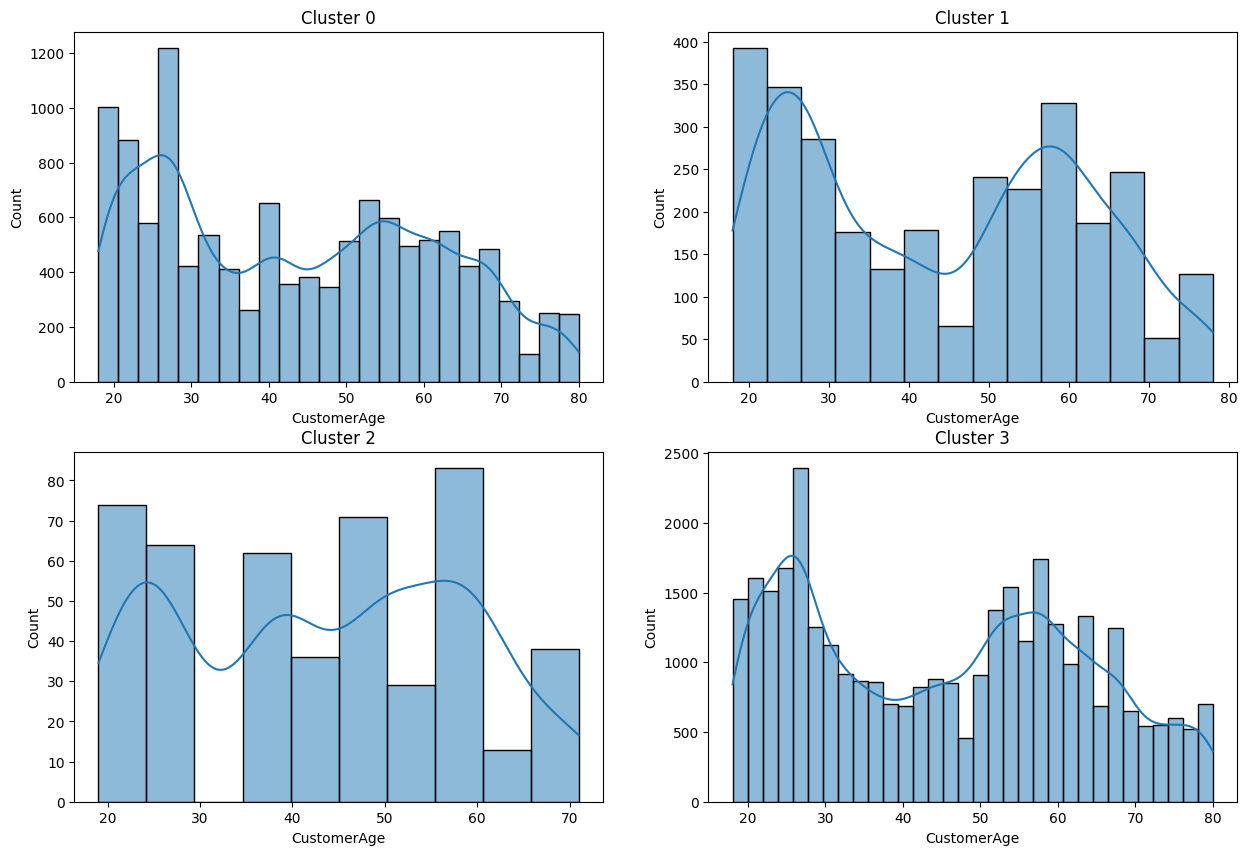

In [452]:
# Age Distribution

fig, axes = plt.subplots(2, 2, figsize=(15, 10))

sns.histplot(data=label0, x="CustomerAge", kde=True, ax=axes[0,0])
sns.histplot(data=label1, x="CustomerAge", kde=True, ax=axes[0,1])
sns.histplot(data=label2, x="CustomerAge", kde=True, ax=axes[1,0])
sns.histplot(data=label3, x="CustomerAge", kde=True, ax=axes[1,1])
axes[0,0].set_title("Cluster 0")
axes[0,1].set_title("Cluster 1")
axes[1,0].set_title("Cluster 2")
axes[1,1].set_title("Cluster 3")

plt.show()

# Conclusion

This project aim was to validate an hypothesis if next transaction level self supervised learning prediction is a valid way to find account level representation. Success of this project is best evaluated if model performs well on downstream tasks like fraud detection, income prediction, credit scoring, clustering, etc.

Based on the fact that this data was synthetically generated and no clear patterns are expected, the model performed poorly on it main optimization goal i.e (Transaction amount and Days between transaction).

Since the goal of this project is to comfirm if the model learned meaningful representations or vectors for each account, using kmeans unsupervised learning algorithm, we were able to group each eaccount into clusters based on their learned representation, the best number of clusters was at 2 (69%) but we picked 4 (45%) because we have the oppurtunities to get more clusters and its the second best based on silhouette score metrics.

Findings showed that cluster 1 has the highest average account balance among the whole group and also the highest credit transaction rate. majority of accounts belongs to cluster 3, this cluster has the highest number of accounts among all age group with emphasis on youths it also has the second highest rate of credit transactions. Cluster 0 has the highest average cashflow value where among it age group, majority of them are youth

### Average Day Between Transaction:
This is one of the self supervised optimization objective, this particular optimization goal was slightly better than the other (Amount transaction prediction) which kept on predicting near 0 values. 

This feature showed that clusters has a clear segmentation:
Cluster 0 has an average of 19 days between transactions
Cluster 1 has 44 days which is the second highest
Cluster 2 has 105 days which is the highest
Cluster 3 has 18 days which is actually the lowest

In conclusion, based on the clustering algorithm result - self supervised representation learning using next transaction prediction can be an effective way of learning account level representation. Application of learned embeddings to supervised learning task is encouraged for further justification